In [11]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import random
import math
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow import keras
from keras import layers, models, Input
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


In [12]:
# Cell 2: Data Generation
breeds_sizes = [
    ("Labrador Retriever", "large"), ("Golden Retriever", "large"), ("German Shepherd", "large"),
    ("Rottweiler", "large"), ("Great Dane", "large"), ("Doberman Pinscher", "large"),
    ("Siberian Husky", "medium"), ("Bulldog", "medium"), ("Boxer", "medium"),
    ("Australian Shepherd", "medium"), ("Border Collie", "medium"), ("Beagle", "small"),
    ("Dachshund", "small"), ("Poodle", "small"), ("Chihuahua", "small"),
    ("French Bulldog", "small"), ("Yorkshire Terrier", "small"), ("Shih Tzu", "small"),
    ("Maltese", "small"), ("Pomeranian", "small"), ("French Griffon", "small")
]
genders = ["Male", "Female"]
num_rows = 50000
username_list = np.random.choice(range(10000, 99999), num_rows, replace=False)

data = {
    "username": username_list,
    "pet_breed": [random.choice(breeds_sizes)[0] for _ in range(num_rows)],
    "size": [random.choice(breeds_sizes)[1] for _ in range(num_rows)],
    "age": np.random.randint(1, 16, num_rows),
    "gender": [random.choice(genders) for _ in range(num_rows)],
    "latitude": np.random.uniform(22.0, 31.0, num_rows),
    "longitude": np.random.uniform(25.0, 36.0, num_rows)
}
df = pd.DataFrame(data)
df.to_csv("petProfiles50k.csv", index=False)

print("Dataset generated and saved to 'petProfiles50k.csv'.")
print("Sample of the data:")
print(df.head())

Dataset generated and saved to 'petProfiles50k.csv'.
Sample of the data:
   username          pet_breed    size  age  gender   latitude  longitude
0     86475         Rottweiler   large   10    Male  25.098822  29.526726
1     22228   Golden Retriever   large   10    Male  25.822365  31.939868
2     11095  Doberman Pinscher   small   10  Female  23.680647  33.917035
3     26893          Dachshund   small    3  Female  23.097294  27.344031
4     87734           Shih Tzu  medium    6  Female  27.084882  33.219110


In [13]:
# Cell 3: Data Preprocessing
df = pd.read_csv('petProfiles50k.csv')
df = pd.get_dummies(df, columns=['pet_breed', 'size', 'gender'])

# Normalize numeric features
scaler = MinMaxScaler()
df[['age', 'latitude', 'longitude']] = scaler.fit_transform(df[['age', 'latitude', 'longitude']])
df = df.astype('float32')

# Split into train and test sets
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

print("Data preprocessed. Info:")
print(df.info())
print(f"Train set size: {len(train_df)}, Test set size: {len(test_df)}")
print("Sample of preprocessed data:")
print(train_df.head())

Data preprocessed. Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 30 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   username                       50000 non-null  float32
 1   age                            50000 non-null  float32
 2   latitude                       50000 non-null  float32
 3   longitude                      50000 non-null  float32
 4   pet_breed_Australian Shepherd  50000 non-null  float32
 5   pet_breed_Beagle               50000 non-null  float32
 6   pet_breed_Border Collie        50000 non-null  float32
 7   pet_breed_Boxer                50000 non-null  float32
 8   pet_breed_Bulldog              50000 non-null  float32
 9   pet_breed_Chihuahua            50000 non-null  float32
 10  pet_breed_Dachshund            50000 non-null  float32
 11  pet_breed_Doberman Pinscher    50000 non-null  float32
 12  pet_breed_French Bull

In [14]:
# Cell 4: Balanced Pair Sampling Function
import math
import numpy as np
from sklearn.metrics.pairwise import haversine_distances

def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2])
    d_lat = lat2 - lat1
    d_lon = lon2 - lon1
    a = math.sin(d_lat / 2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(d_lon / 2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    return R * c

def create_balanced_pairs(df_subset, num_pairs_per_class=20000, max_distance=100.0, max_age_diff=6.0):
    data = df_subset.values
    columns = df_subset.columns
    breed_cols = [c for c in columns if c.startswith('pet_breed_')]
    size_cols = [c for c in columns if c.startswith('size_')]
    gender_cols = [c for c in columns if c.startswith('gender_')]
    lat_idx = columns.get_loc('latitude')
    lon_idx = columns.get_loc('longitude')
    age_idx = columns.get_loc('age')
    breed_indices = [columns.get_loc(c) for c in breed_cols]
    size_indices = [columns.get_loc(c) for c in size_cols]
    gender_indices = [columns.get_loc(c) for c in gender_cols]
    idx_male = gender_indices[0] if 'gender_Male' in columns else None
    idx_female = gender_indices[1] if 'gender_Female' in columns else None

    # Precompute unscaled values
    lats = data[:, lat_idx] * 9 + 22
    lons = data[:, lon_idx] * 11 + 25
    ages = data[:, age_idx] * 15

    # Pre-filter: Find potential positive pairs (opposite gender, within max_distance)
    males = np.where(data[:, idx_male] > 0.5)[0]
    females = np.where(data[:, idx_female] > 0.5)[0]
    coords = np.stack([lats, lons], axis=1)
    coords = np.radians(coords)
    dist_matrix = haversine_distances(coords, coords) * 6371.0  # In km

    potential_pos_pairs = []
    for m in males:
        for f in females:
            if m == f:
                continue
            dist = dist_matrix[m, f]
            if dist <= max_distance:
                potential_pos_pairs.append((m, f))

    pairs, labels = [], []
    pos_count, neg_count = 0, 0
    n = len(data)

    # Positive pairs from pre-filtered set
    np.random.shuffle(potential_pos_pairs)
    for i, j in potential_pos_pairs:
        if pos_count >= num_pairs_per_class:
            break
        petA, petB = data[i], data[j]
        age_diff = abs(ages[i] - ages[j])
        same_breed = any(petA[idx] > 0.5 and petB[idx] > 0.5 for idx in breed_indices)
        same_size = any(petA[idx] > 0.5 and petB[idx] > 0.5 for idx in size_indices)

        # Stricter criteria for positive pairs
        if age_diff <= max_age_diff and same_breed and same_size:
            pairs.append([petA, petB])
            labels.append(1.0)
            pos_count += 1

    # Negative pairs
    while neg_count < num_pairs_per_class:
        i, j = np.random.randint(0, n, 2)
        if i == j:
            continue
        petA, petB = data[i], data[j]
        opp_gender = (petA[idx_male] > 0.5 and petB[idx_female] > 0.5) or (petA[idx_female] > 0.5 and petB[idx_male] > 0.5)
        dist = dist_matrix[i, j]
        age_diff = abs(ages[i] - ages[j])
        same_breed = any(petA[idx] > 0.5 and petB[idx] > 0.5 for idx in breed_indices)
        same_size = any(petA[idx] > 0.5 and petB[idx] > 0.5 for idx in size_indices)

        # Negative if it fails any key criterion
        if not (opp_gender and dist <= max_distance and age_diff <= max_age_diff and same_breed and same_size):
            pairs.append([petA, petB])
            labels.append(0.0)
            neg_count += 1

    pairs = np.array(pairs, dtype='float32')
    labels = np.array(labels, dtype='float32')
    return pairs, labels

print("Pair sampling function defined.")

Pair sampling function defined.


In [15]:
# Cell 5: Generate Pairs
pairs_train, labels_train = create_balanced_pairs(train_df, num_pairs_per_class=20000, max_distance=100.0, max_age_diff=6.0)
pairs_val, labels_val = create_balanced_pairs(test_df, num_pairs_per_class=5000, max_distance=100.0, max_age_diff=6.0)
pet_features_1_train, pet_features_2_train = pairs_train[:, 0], pairs_train[:, 1]
pet_features_1_val, pet_features_2_val = pairs_val[:, 0], pairs_val[:, 1]

print(f"Train pairs shape: {pairs_train.shape}, Labels shape: {labels_train.shape}")
print(f"Validation pairs shape: {pairs_val.shape}, Labels shape: {labels_val.shape}")
print(f"Train positive pairs ratio: {labels_train.mean():.3f}")
print(f"Validation positive pairs ratio: {labels_val.mean():.3f}")

Train pairs shape: (40000, 2, 30), Labels shape: (40000,)
Validation pairs shape: (10000, 2, 30), Labels shape: (10000,)
Train positive pairs ratio: 0.500
Validation positive pairs ratio: 0.500


In [20]:
# Cell 6: Define Siamese Model
def create_subnetwork(input_shape):
    inp = Input(shape=input_shape)
    x = layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(32, activation='relu')(x)
    return models.Model(inp, x)

def contrastive_loss(y_true, y_pred, margin=1.0):
    y_true = tf.cast(y_true, tf.float32)
    square_pred = tf.square(y_pred)
    margin_square = tf.square(tf.maximum(margin - y_pred, 0))
    return tf.reduce_mean(y_true * square_pred + (1 - y_true) * margin_square)

input_shape = (pet_features_1_train.shape[1],)
pet_network = create_subnetwork(input_shape)

input_pet1 = Input(shape=input_shape)
input_pet2 = Input(shape=input_shape)
embedding_pet1 = pet_network(input_pet1)
embedding_pet2 = pet_network(input_pet2)

# Compute Euclidean distance
distance = layers.Lambda(lambda embeddings: tf.sqrt(tf.reduce_sum(tf.square(embeddings[0] - embeddings[1]), axis=1, keepdims=True)))([embedding_pet1, embedding_pet2])

# Add a dense layer with sigmoid to predict compatibility
output = layers.Dense(1, activation='sigmoid', name='compatibility')(distance)

model = models.Model(inputs=[input_pet1, input_pet2], outputs=output)

# Compile with binary cross-entropy to directly optimize for classification
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), 
              loss='binary_crossentropy', 
              metrics=['accuracy'])

model.summary()

Model: "model_5"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_8 (InputLayer)           [(None, 30)]         0           []                               
                                                                                                  
 input_9 (InputLayer)           [(None, 30)]         0           []                               
                                                                                                  
 model_4 (Functional)           (None, 32)           52960       ['input_8[0][0]',                
                                                                  'input_9[0][0]']                
                                                                                                  
 lambda_1 (Lambda)              (None, 1)            0           ['model_4[0][0]',          

Epoch 1/50
157/157 [==============================] - 4s 14ms/step - loss: 4.0514 - accuracy: 0.5000 - val_loss: 1.2504 - val_accuracy: 0.5001 - lr: 1.0000e-04
Epoch 2/50
157/157 [==============================] - 2s 13ms/step - loss: 3.0912 - accuracy: 0.5000 - val_loss: 1.1509 - val_accuracy: 0.4997 - lr: 1.0000e-04
Epoch 3/50
157/157 [==============================] - 2s 12ms/step - loss: 2.4243 - accuracy: 0.5000 - val_loss: 0.9774 - val_accuracy: 0.5016 - lr: 1.0000e-04
Epoch 4/50
157/157 [==============================] - 2s 13ms/step - loss: 2.0451 - accuracy: 0.5000 - val_loss: 0.8668 - val_accuracy: 0.4993 - lr: 1.0000e-04
Epoch 5/50
157/157 [==============================] - 2s 13ms/step - loss: 1.7958 - accuracy: 0.5000 - val_loss: 0.7993 - val_accuracy: 0.4982 - lr: 1.0000e-04
Epoch 6/50
157/157 [==============================] - 2s 13ms/step - loss: 1.6043 - accuracy: 0.5000 - val_loss: 0.7566 - val_accuracy: 0.4956 - lr: 1.0000e-04
Epoch 7/50
157/157 [====================

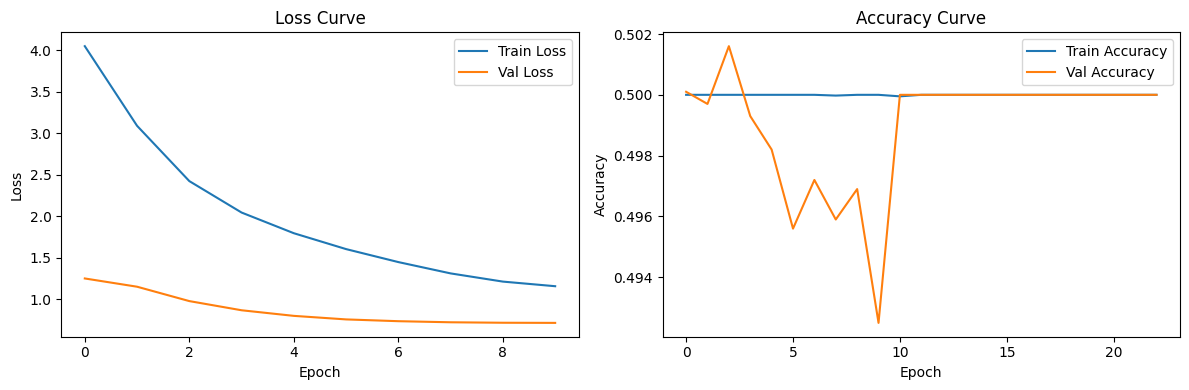

In [21]:
# Cell 7: Prepare Datasets and Train Model
train_dataset = tf.data.Dataset.from_tensor_slices(((pet_features_1_train, pet_features_2_train), labels_train))
train_dataset = train_dataset.shuffle(2048).batch(256).prefetch(tf.data.AUTOTUNE)
val_dataset = tf.data.Dataset.from_tensor_slices(((pet_features_1_val, pet_features_2_val), labels_val))
val_dataset = val_dataset.batch(256).prefetch(tf.data.AUTOTUNE)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=20, restore_best_weights=True, mode='max'),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=5, mode='max')
]

history = model.fit(train_dataset, 
                    validation_data=val_dataset, 
                    epochs=50, 
                    callbacks=callbacks)

print("Training completed.")

# Plot training curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

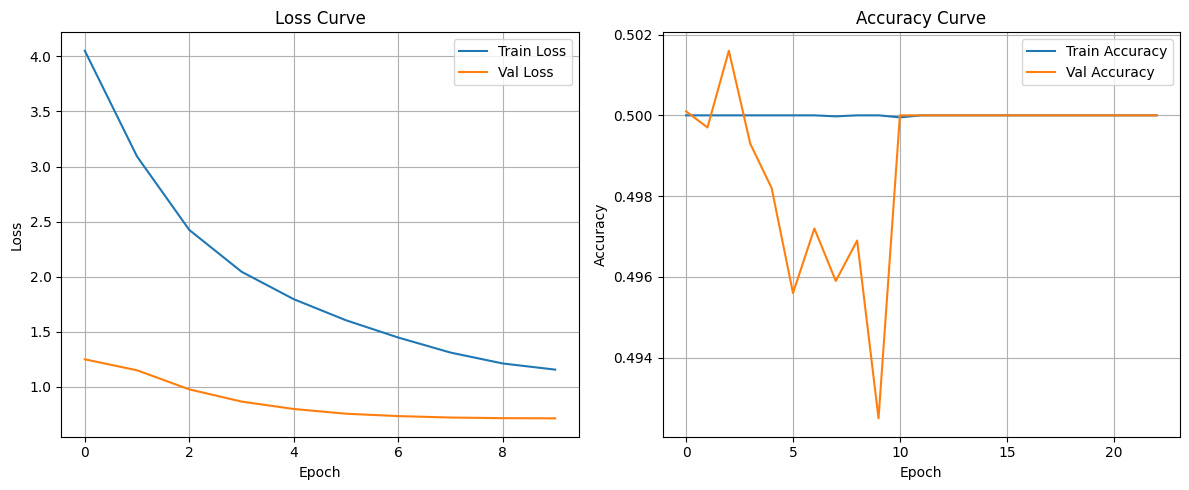

40/40 [==============================] - 0s 4ms/step - loss: 0.9774 - accuracy: 0.5016
Final Validation Loss: 0.9774, Accuracy: 0.5016


In [22]:
# Cell 8: Visualize Training Results
plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

val_loss, val_acc = model.evaluate(val_dataset)
print(f"Final Validation Loss: {val_loss:.4f}, Accuracy: {val_acc:.4f}")

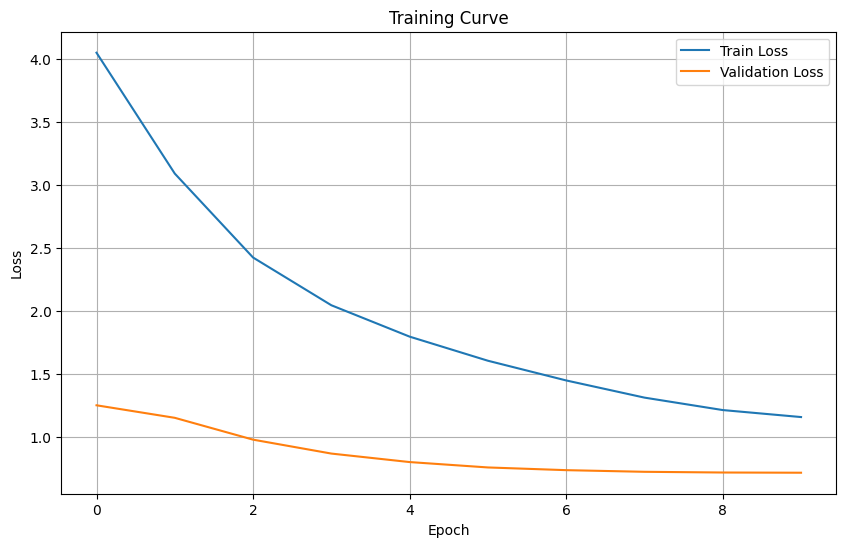

40/40 [==============================] - 0s 4ms/step - loss: 0.9774 - accuracy: 0.5016

Final Validation Loss: [0.9774150252342224, 0.5016000270843506]


In [23]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
if 'val_loss' in history.history:
    plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Curve')
plt.legend()
plt.grid(True)
plt.show()

val_loss = model.evaluate(val_dataset)
print("\nFinal Validation Loss:", val_loss)
